# Joystick coordinate check

Set a BCI2000 `.dat` path below, then run the cells to see whether joystick X/Y coordinates are stored and inspect their values.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from BCI2000Tools.FileReader import bcistream

## 1. Set the `.dat` file path

Edit `DAT_PATH` to point at your file, then run this cell.

In [2]:
# Change this to your .dat file path
DAT_PATH = Path(r"C:\Users\gabri\Desktop\joystick_test_env\python_da\NameS001R05.dat")

if not DAT_PATH.is_file():
    raise FileNotFoundError(f"File not found: {DAT_PATH}")

print(f"Using: {DAT_PATH.resolve()}")

Using: C:\Users\gabri\Desktop\joystick_test_env\python_da\NameS001R05.dat


## 2. Load the file and look for joystick states

In [3]:
JOYSTICK_STATE_CANDIDATES = {
    "x": ("JoystickX", "JoyX", "JoystickPosX", "AnalogX", "CursorX"),
    "y": ("JoystickY", "JoyY", "JoystickPosY", "AnalogY", "CursorY"),
}

stream = bcistream(str(DAT_PATH))
state_names = sorted(stream.statedefs.keys())
params = stream.params

def find_axis(axis: str):
    return next((name for name in JOYSTICK_STATE_CANDIDATES[axis] if name in stream.statedefs), None)

x_state = find_axis("x")
y_state = find_axis("y")
stores_xy = x_state is not None and y_state is not None

app_chain = params.get("ApplicationFilterChain", [])
app_modules = [row[0] for row in app_chain] if app_chain else []

print(f"File: {DAT_PATH.resolve()}")
print(f"Recording: {stream.nchan} channels, {stream.samples()} samples @ {stream.samplingfreq_hz} Hz")
print(f"Application modules: {', '.join(app_modules) if app_modules else '(none)'}")
print(f"SerialPort: {params.get('SerialPort', '(none)')}")
print()

if stores_xy:
    print("RESULT: YES - this file stores joystick X and Y coordinates.")
elif x_state or y_state:
    print("RESULT: PARTIAL - only one joystick axis state was found.")
else:
    print("RESULT: NO - no JoystickX / JoystickY (or known aliases) found in states.")

print(f"  X state: {x_state}")
print(f"  Y state: {y_state}")

joy_like = [n for n in state_names if "joy" in n.lower() or "cursor" in n.lower()]
print(f"\nJoystick/cursor-related states: {', '.join(joy_like) if joy_like else '(none)'}")
print(f"\nAll states ({len(state_names)}):")
print(", ".join(state_names))

File: C:\Users\gabri\Desktop\joystick_test_env\python_da\NameS001R05.dat
Recording: 16 channels, 2876000 samples @ 30000.0 Hz
Application modules: arduino_joystick_Task, KeystrokeFilter, ParallelPortFilter
SerialPort: COM3

RESULT: YES - this file stores joystick X and Y coordinates.
  X state: JoystickX
  Y state: JoystickY

Joystick/cursor-related states: CursorX, CursorY, JoystickButton, JoystickX, JoystickY

All states (34):
AudioBufferTime, AudioPresentationTime, CursorX, CursorY, FilePart, JoystickButton, JoystickX, JoystickY, MovementStarted, MovementTimeMs, Notes, PreStimulusTime, PresentationDisplayed, PresentationFrame, PresentationRequested, PresentationTime, ReactionTimeMs, Recording, Running, SourceChannel1, SourceTime, StimulusTime, TargetHit, TargetIndex, TaskBlock, TaskCondition, TaskPhase, TaskTrial, TotalTimeMs, VideoStimulusFrame, __pad0, __pad1, __pad2, __pad3


## 3. Decode and summarize axis / task states

In [4]:
wanted = [name for name in (x_state, y_state) if name]
for extra in ("JoystickButton", "TaskPhase", "TargetIndex", "CursorX", "CursorY", "TaskTrial", "TargetHit"):
    if extra in stream.statedefs and extra not in wanted:
        wanted.append(extra)

sig, states = stream.decode(nsamp="all", states=wanted or "all")
sig = np.asarray(sig)

rows = []
for name in wanted:
    a = np.asarray(states[name]).ravel()
    rows.append({
        "state": name,
        "min": a.min(),
        "max": a.max(),
        "mean": a.mean(),
        "n_unique": np.unique(a).size,
        "n_changes": int(np.count_nonzero(np.diff(a))),
        "n_samples": a.size,
    })

summary_df = pd.DataFrame(rows).set_index("state")
summary_df

,min,max,mean,n_unique,n_changes,n_samples
state,,,,,,
JoystickX,39,930,489.949207,262,1412,2876000
JoystickY,32,1023,528.774353,377,1048,2876000
JoystickButton,1,1,1.000000,1,0,2876000
TaskPhase,0,5,2.760834,6,60,2876000
TargetIndex,0,5,3.137836,5,7,2876000
CursorX,93,984,527.108050,276,1413,2876000
CursorY,0,1023,526.551255,392,1049,2876000
TaskTrial,0,10,6.074170,11,10,2876000
TargetHit,0,1,0.000100,2,18,2876000


## 4. Plot joystick X/Y over time

Runs only if X and Y states were found.

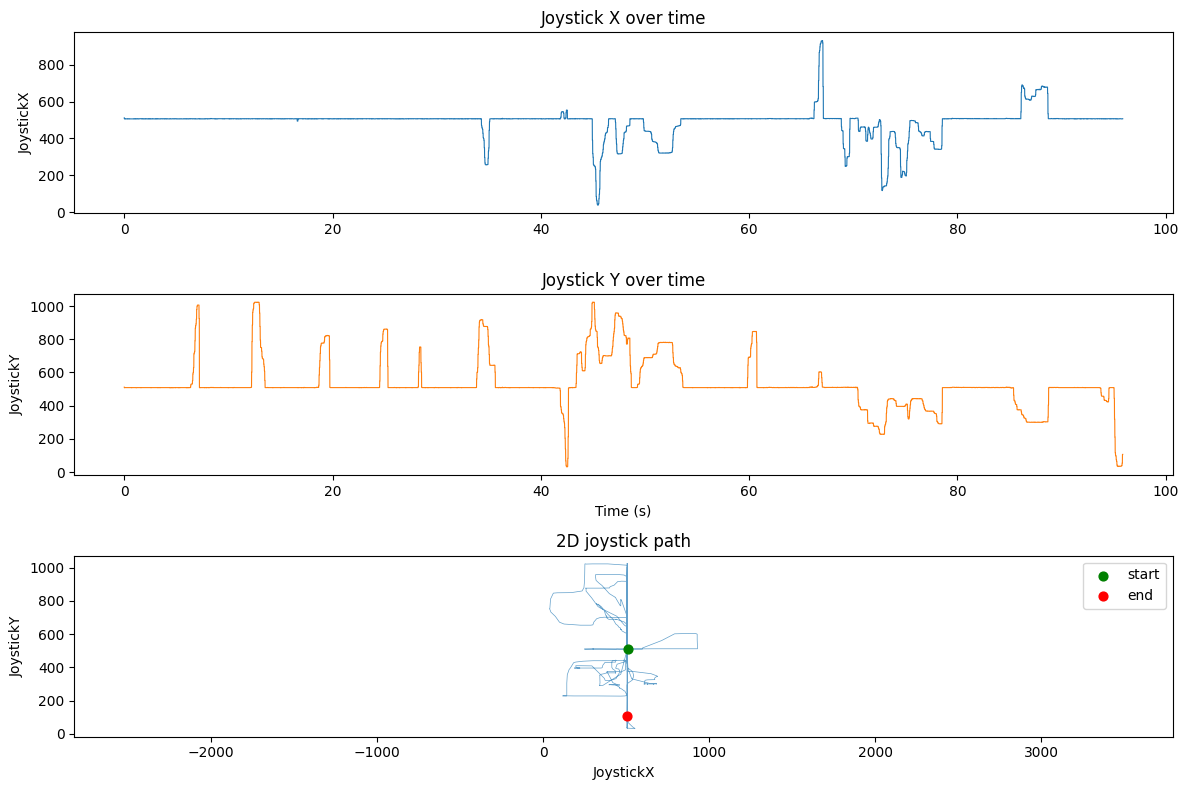

JoystickX: min=39, max=930, unique=262
JoystickY: min=32, max=1023, unique=377


In [5]:
if not stores_xy:
    print("Skipping plot: joystick X/Y states not both present.")
else:
    t = np.arange(stream.samples()) / stream.samplingfreq_hz
    jx = np.asarray(states[x_state]).ravel()
    jy = np.asarray(states[y_state]).ravel()

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

    axes[0].plot(t, jx, lw=0.8)
    axes[0].set_ylabel(x_state)
    axes[0].set_title("Joystick X over time")

    axes[1].plot(t, jy, lw=0.8, color="C1")
    axes[1].set_ylabel(y_state)
    axes[1].set_xlabel("Time (s)")
    axes[1].set_title("Joystick Y over time")

    axes[2].plot(jx, jy, lw=0.5, alpha=0.7)
    axes[2].scatter(jx[0], jy[0], c="green", s=40, zorder=3, label="start")
    axes[2].scatter(jx[-1], jy[-1], c="red", s=40, zorder=3, label="end")
    axes[2].set_xlabel(x_state)
    axes[2].set_ylabel(y_state)
    axes[2].set_title("2D joystick path")
    axes[2].legend()
    axes[2].set_aspect("equal", adjustable="datalim")

    fig.tight_layout()
    plt.show()

    print(f"{x_state}: min={jx.min()}, max={jx.max()}, unique={np.unique(jx).size}")
    print(f"{y_state}: min={jy.min()}, max={jy.max()}, unique={np.unique(jy).size}")

## 5. Optional: peek at signal channels

Useful to confirm whether X/Y live in states vs. the continuous signal channels.

In [ ]:
channel_names = list(params.get("ChannelNames") or [])
if len(channel_names) < sig.shape[0]:
    channel_names = [f"ch{i}" for i in range(sig.shape[0])]

chan_rows = []
for i in range(sig.shape[0]):
    ch = np.asarray(sig[i]).ravel()
    chan_rows.append({
        "channel": channel_names[i],
        "min": float(ch.min()),
        "max": float(ch.max()),
        "mean": float(ch.mean()),
        "std": float(ch.std()),
    })

channel_df = pd.DataFrame(chan_rows).set_index("channel")
channel_df

,min,max,mean,std
channel,,,,
ch0,-171.500000,171.500000,0.031286,91.463463
ch1,-171.500000,171.500000,0.025448,91.459854
ch2,-171.500000,171.500000,0.028383,91.452789
ch3,-171.600006,171.600006,0.035716,91.462631
ch4,-171.500000,171.500000,0.037273,91.460991
ch5,-171.600006,171.400009,0.037853,91.461807
ch6,-171.600006,171.500000,0.025483,91.463943
ch7,-171.500000,171.500000,0.026333,91.461754
ch8,-171.500000,171.600006,0.042097,91.461006


: 